In [661]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

# now i will just discovered the columns

In [662]:
df = pd.read_csv('./data.csv')

In [663]:
df.head()

,Property_id,Offer,URL,Property_type,Include_w_e,Title,Area,Governorate,Beds,Baths,Size,Availability_date,Agent_name,Agency,Amenities,rent
0,6046,Rent,https://www.propertyfinder.bh/en/plp/rent/vill...,Villa,Inclusive,BTRAND NEW LUXURY VILLA FOR RENT AMWAJ,"Amwaj Avenue, Amwaj Islands",Muharraq Governorate,3+ Maid,4,"2,368 sqft / 220 sqm",9 Apr 2025,Savio Fernandes,Almoayyed property solutions,6.0,1000.0
1,2240,Rent,https://www.propertyfinder.bh/en/plp/rent/vill...,Villa,Exclusive,First Resident | Quiet Area | Luxurious,Diyar Al Muharraq,Muharraq Governorate,5,6,"3,229 sqft / 300 sqm",16 Sep 2025,Al Lagoon Real Estate,Al Lagoon Real Estate,5.0,700.0
2,6248,Rent,https://www.propertyfinder.bh/en/plp/rent/apar...,Apartment,Inclusive,Studio Apartment for rent located in Juffair,Al Juffair,Capital Governorate,studio,1,484 sqft / 45 sqm,17 Aug 2025,Najeeb Hejres,Green Line Real Estate,12.0,260.0
3,7177,Rent,https://www.propertyfinder.bh/en/plp/rent/apar...,Apartment,Exclusive,Apartment for Rent in Jidhafs – Prime Location,Jidhafs,Northern Governorate,3,3,"1,507 sqft / 140 sqm",6 Aug 2025,Sayed Sadeq Jaafar,Grnata Real Estate,2.0,250.0
4,7842,Rent,https://www.propertyfinder.bh/en/plp/rent/vill...,Villa,Exclusive,Navy Approved| 5 BR | Private Pool |Gardens,Al Juffair,Capital Governorate,5+ Maid,5,"4,844 sqft / 450 sqm",30 Jul 2025,Zsuzsanna Gecse,Arabian Homes Properties,13.0,1280.0


In [664]:
df.shape

(10578, 16)

In [665]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10578 entries, 0 to 10577
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Property_id        10578 non-null  int64  
 1   Offer              10578 non-null  str    
 2   URL                10578 non-null  str    
 3   Property_type      10578 non-null  str    
 4   Include_w_e        10578 non-null  str    
 5   Title              10575 non-null  str    
 6   Area               10575 non-null  str    
 7   Governorate        10575 non-null  str    
 8   Beds               10578 non-null  str    
 9   Baths              10578 non-null  str    
 10  Size               10578 non-null  str    
 11  Availability_date  10059 non-null  str    
 12  Agent_name         10575 non-null  str    
 13  Agency             10575 non-null  str    
 14  Amenities          10272 non-null  float64
 15  rent               10575 non-null  float64
dtypes: float64(2), int64(1), str(13)


In [666]:
df['Offer'].unique()

<ArrowStringArray>
['Rent']
Length: 1, dtype: str

In [667]:
df['Include_w_e'].value_counts()

Include_w_e
Inclusive    6477
Exclusive    4101
Name: count, dtype: int64

In [668]:
df['Property_type'].value_counts()

Property_type
Apartment                       8378
Villa                           1855
Compound                         133
Duplex                            95
Penthouse                         69
Townhouse                         21
Whole Building                    18
Hotel Apartment                    6
Bulk Rent Unit                     1
Short Term & Hotel Apartment       1
Bungalow                           1
Name: count, dtype: int64

In [669]:
df.isnull().sum()

Property_id            0
Offer                  0
URL                    0
Property_type          0
Include_w_e            0
Title                  3
Area                   3
Governorate            3
Beds                   0
Baths                  0
Size                   0
Availability_date    519
Agent_name             3
Agency                 3
Amenities            306
rent                   3
dtype: int64

In [670]:
df['Size']

0        2,368 sqft / 220 sqm
1        3,229 sqft / 300 sqm
2           484 sqft / 45 sqm
3        1,507 sqft / 140 sqm
4        4,844 sqft / 450 sqm
                 ...         
10573    1,453 sqft / 135 sqm
10574    1,292 sqft / 120 sqm
10575       980 sqft / 91 sqm
10576    4,306 sqft / 400 sqm
10577       861 sqft / 80 sqm
Name: Size, Length: 10578, dtype: str

# Time to cleaning

In [671]:
df = df.dropna(subset=['Governorate'])

In [672]:
print(df['Property_id'].dtype)
print()
print(df['Property_id'].describe())
print()
print(df['Property_id'].isnull().sum())
print()
print(df['Property_id'].duplicated().sum())

int64

count    10575.000000
mean      7060.870638
std       4080.314274
min          2.000000
25%       3523.000000
50%       7024.000000
75%      10606.500000
max      14103.000000
Name: Property_id, dtype: float64

0

0


In [673]:
print(df['Offer'].dtype)
print()
print(df['Offer'].describe())
print()
print(df['Offer'].isnull().sum())
print()
print(df['Offer'].duplicated().sum())

str

count     10575
unique        1
top        Rent
freq      10575
Name: Offer, dtype: object

0

10574


In [674]:
print(df['URL'].dtype)
print()
print(df['URL'].describe())
print()
print(df['URL'].isnull().sum())
print()
print(df['URL'].duplicated().sum())

str

count                                                 10575
unique                                                10335
top       https://www.propertyfinder.bh/en/plp/rent/apar...
freq                                                      5
Name: URL, dtype: object

0

240


In [675]:
print(df['Property_type'].dtype)
print()
print(df['Property_type'].describe())
print()
print(df['Property_type'].isnull().sum())
print()
print(df['Property_type'].duplicated().sum())


str

count         10575
unique           11
top       Apartment
freq           8375
Name: Property_type, dtype: object

0

10564


In [676]:
print(df['Property_type'].value_counts())
rare_props = df['Property_type'].value_counts()[df['Property_type'].value_counts() < 20].index
df['Property_type'] = df['Property_type'].apply(lambda x: 'Other' if x in rare_props else x)
#There are some rare types that we have combined.

Property_type
Apartment                       8375
Villa                           1855
Compound                         133
Duplex                            95
Penthouse                         69
Townhouse                         21
Whole Building                    18
Hotel Apartment                    6
Bulk Rent Unit                     1
Short Term & Hotel Apartment       1
Bungalow                           1
Name: count, dtype: int64


In [677]:
print(df['Include_w_e'].dtype)
print()
print(df['Include_w_e'].describe())
print()
print(df['Include_w_e'].isnull().sum())
print()
print(df['Include_w_e'].duplicated().sum())



str

count         10575
unique            2
top       Inclusive
freq           6476
Name: Include_w_e, dtype: object

0

10573


In [678]:
print(df['Title'].dtype)
print()
print(df['Title'].describe())
print()
print(df['Title'].isnull().sum())
print()
print(df['Title'].duplicated().sum())
#The title is not a feature, so there is no need to clean it.

str

count                                         10575
unique                                         9824
top       Apartment for rent , in a great location:
freq                                             18
Name: Title, dtype: object

0

751


In [679]:
print(df['Area'].dtype)
print()
print(df['Area'].describe())
print()
print(df['Area'].isnull().sum())
print()
print(df['Area'].duplicated().sum())
df['Area'].value_counts()

str

count          10575
unique           127
top       Al Juffair
freq            1914
Name: Area, dtype: object

0

10448


Area
Al Juffair                                              1914
Seef                                                    1025
Saar                                                     704
Janabiya                                                 535
Hidd                                                     496
                                                        ... 
Buri                                                       1
Al Thurya villa Diyar Al Muharraq, Diyar Al Muharraq       1
Dareena, Dilmunia Island                                   1
Wahat Al Muharraq                                          1
Adhari, Manama                                             1
Name: count, Length: 127, dtype: int64

In [680]:
df['Area'] = df['Area'].fillna('Other')

df['Area'] = df['Area'].apply(lambda x: x if df['Area'].value_counts().get(x, 0) >= 10 else 'Other')

df['Area'] = df['Area'].apply(lambda x: x if df['Area'].value_counts()[x] >= 10 else 'Other')
#There are some rare types that we have combined.

In [681]:
df['Area'].value_counts().sum()

np.int64(10575)

In [682]:
# print(df['Governorate'].dtype)
# print()
# print(df['Governorate'].describe())
# print()
print(df['Governorate'].isnull().sum())
# print()
# print(df['Governorate'].duplicated().sum())
print(df['Governorate'].value_counts())

0
Governorate
Capital Governorate     5308
Muharraq Governorate    2844
Northern Governorate    1857
Central Governorate      316
Southern Governorate     250
Name: count, dtype: int64


In [683]:
print(df[df['Governorate'].isnull()])

Empty DataFrame
Columns: [Property_id, Offer, URL, Property_type, Include_w_e, Title, Area, Governorate, Beds, Baths, Size, Availability_date, Agent_name, Agency, Amenities, rent]
Index: []


In [684]:
df.shape

(10575, 16)

In [685]:
print(df['Beds'].dtype)
print()
print(df['Beds'].describe())
print()
print(df['Beds'].isnull().sum())
print()
print(df['Beds'].duplicated().sum())


str

count     10575
unique       19
top           2
freq       3871
Name: Beds, dtype: object

0

10556


In [686]:
df['Beds'].value_counts()

Beds
2               3871
1               2201
3               1332
4+ Maid          832
3+ Maid          748
studio           595
2+ Maid          283
5+ Maid          253
4                236
5                 63
1+ Maid           49
6+ Maid           41
6                 20
7+                18
studio+ Maid       9
7++ Maid           7
7                  7
7+ Maid            7
0                  3
Name: count, dtype: int64

In [687]:
# #هالكود يخلينا نصنف الاستيديو الى صفر غرف , وغرفة الخادمة نحسبها في كولوم بروحها ,
# #استخدمت مكتبة يديدة مهمتها تسوي سيرج



def clean_beds(val):
    val = str(val).strip()
    has_maid = 'Maid' in val
    
    if val.startswith('7+'):
        if '++' in val:
            is_open_ended = True
        elif has_maid:
            is_open_ended = False
        else:
            is_open_ended = True
    else:
        is_open_ended = False
    
    if 'studio' in val.lower():
        beds = 0
    else:
        match = re.search(r'\d+', val)
        beds = int(match.group()) if match else None
    
    return pd.Series({
        'beds_clean': beds,
        'has_maid_room': int(has_maid),
        'is_open_ended': int(is_open_ended)
    })

df[['beds_clean', 'has_maid_room', 'is_open_ended']] = df['Beds'].apply(clean_beds)

In [688]:
df['beds_clean'].value_counts()
df['has_maid_room'].value_counts()

has_maid_room
0    8346
1    2229
Name: count, dtype: int64

In [689]:
df['Area'].value_counts().sum()

np.int64(10575)

In [690]:
df['Beds'].value_counts()

Beds
2               3871
1               2201
3               1332
4+ Maid          832
3+ Maid          748
studio           595
2+ Maid          283
5+ Maid          253
4                236
5                 63
1+ Maid           49
6+ Maid           41
6                 20
7+                18
studio+ Maid       9
7++ Maid           7
7                  7
7+ Maid            7
0                  3
Name: count, dtype: int64

In [691]:
df['beds_clean'].value_counts()

beds_clean
2    4154
1    2250
3    2080
4    1068
0     607
5     316
6      61
7      39
Name: count, dtype: int64

In [692]:
df['Baths'].value_counts()

Baths
2       4259
3       2427
1       1583
4       1217
5        739
6        222
7         83
7+        44
none       1
Name: count, dtype: int64

In [693]:
df['is_open_ended'].value_counts()

is_open_ended
0    10550
1       25
Name: count, dtype: int64

In [694]:
df['has_maid_room'].value_counts()


has_maid_room
0    8346
1    2229
Name: count, dtype: int64

In [695]:
df.info()

<class 'pandas.DataFrame'>
Index: 10575 entries, 0 to 10577
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Property_id        10575 non-null  int64  
 1   Offer              10575 non-null  str    
 2   URL                10575 non-null  str    
 3   Property_type      10575 non-null  str    
 4   Include_w_e        10575 non-null  str    
 5   Title              10575 non-null  str    
 6   Area               10575 non-null  str    
 7   Governorate        10575 non-null  str    
 8   Beds               10575 non-null  str    
 9   Baths              10575 non-null  str    
 10  Size               10575 non-null  str    
 11  Availability_date  10059 non-null  str    
 12  Agent_name         10575 non-null  str    
 13  Agency             10575 non-null  str    
 14  Amenities          10269 non-null  float64
 15  rent               10575 non-null  float64
 16  beds_clean         10575 non-null  int

In [696]:
df['Baths'].value_counts()

Baths
2       4259
3       2427
1       1583
4       1217
5        739
6        222
7         83
7+        44
none       1
Name: count, dtype: int64

In [697]:
df[df['Baths']=='none']

,Property_id,Offer,URL,Property_type,Include_w_e,Title,Area,Governorate,Beds,Baths,Size,Availability_date,Agent_name,Agency,Amenities,rent,beds_clean,has_maid_room,is_open_ended
4378,13335,Rent,https://www.propertyfinder.bh/en/plp/rent/comp...,Compound,Exclusive,Spacious Compound Area for Rent in Hidd,Hidd,Muharraq Governorate,studio,none,"4,306 sqft / 400 sqm",19 May 2024,Rashed Alnaham,Al Naham Real Estate,NaN,350.0,0,0,0


In [698]:
df['Property_type'].value_counts()

Property_type
Apartment    8375
Villa        1855
Compound      133
Duplex         95
Penthouse      69
Other          27
Townhouse      21
Name: count, dtype: int64

In [699]:
df['Baths'].value_counts()

Baths
2       4259
3       2427
1       1583
4       1217
5        739
6        222
7         83
7+        44
none       1
Name: count, dtype: int64

In [700]:
print(df['Baths'].unique())

<ArrowStringArray>
['4', '6', '1', '3', '5', '2', '7+', '7', 'none']
Length: 9, dtype: str


In [701]:

def clean_baths(val):
    val = str(val).strip()
    
    if val.lower() == 'none' or val.lower() == 'nan':
        return pd.Series({'baths_clean': None, 'baths_open_ended': 0})
    
    is_open_ended = 1 if '+' in val else 0
    match = re.search(r'\d+', val)
    baths = int(match.group()) if match else None
    
    return pd.Series({'baths_clean': baths, 'baths_open_ended': is_open_ended})

result = df['Baths'].apply(clean_baths)
df['baths_clean'] = result['baths_clean']
df['baths_open_ended'] = result['baths_open_ended']

print(df['baths_open_ended'].value_counts())

baths_open_ended
0.0    10531
1.0       44
Name: count, dtype: int64


In [702]:
df.info()

<class 'pandas.DataFrame'>
Index: 10575 entries, 0 to 10577
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Property_id        10575 non-null  int64  
 1   Offer              10575 non-null  str    
 2   URL                10575 non-null  str    
 3   Property_type      10575 non-null  str    
 4   Include_w_e        10575 non-null  str    
 5   Title              10575 non-null  str    
 6   Area               10575 non-null  str    
 7   Governorate        10575 non-null  str    
 8   Beds               10575 non-null  str    
 9   Baths              10575 non-null  str    
 10  Size               10575 non-null  str    
 11  Availability_date  10059 non-null  str    
 12  Agent_name         10575 non-null  str    
 13  Agency             10575 non-null  str    
 14  Amenities          10269 non-null  float64
 15  rent               10575 non-null  float64
 16  beds_clean         10575 non-null  int

In [703]:
#just to impute the nall one
df['baths_was_missing'] = df['baths_clean'].isna().astype(int)

df['baths_clean'] = df.groupby('Property_type')['baths_clean'].transform(
    lambda x: x.fillna(x.median())
)
df['baths_clean'] = df['baths_clean'].fillna(df['baths_clean'].median())

In [704]:
df['Size'].head()

0    2,368 sqft / 220 sqm
1    3,229 sqft / 300 sqm
2       484 sqft / 45 sqm
3    1,507 sqft / 140 sqm
4    4,844 sqft / 450 sqm
Name: Size, dtype: str

In [705]:

def clean_size(val):
    val = str(val).strip()
    
    numbers = re.findall(r'[\d,]+', val)
    numbers = [float(n.replace(',', '')) for n in numbers]
    
    sqft = numbers[0] if len(numbers) > 0 else None
    sqm = numbers[1] if len(numbers) > 1 else None
    
    return pd.Series({'size_sqft': sqft, 'size_sqm': sqm})

df[['size_sqft', 'size_sqm']] = df['Size'].apply(clean_size)

In [706]:

df = df.drop(columns=['size_sqft']) 
df = df.rename(columns={'size_sqm': 'size_clean'})

In [707]:
df['size_clean']

0        220.0
1        300.0
2         45.0
3        140.0
4        450.0
         ...  
10573    135.0
10574    120.0
10575     91.0
10576    400.0
10577     80.0
Name: size_clean, Length: 10575, dtype: float64

In [708]:
df['Availability_date'].describe()

count          10059
unique           608
top       9 Sep 2025
freq             190
Name: Availability_date, dtype: object

In [709]:
df['Availability_date'].isna().sum()

np.int64(516)

In [710]:
df.info()

<class 'pandas.DataFrame'>
Index: 10575 entries, 0 to 10577
Data columns (total 23 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Property_id        10575 non-null  int64  
 1   Offer              10575 non-null  str    
 2   URL                10575 non-null  str    
 3   Property_type      10575 non-null  str    
 4   Include_w_e        10575 non-null  str    
 5   Title              10575 non-null  str    
 6   Area               10575 non-null  str    
 7   Governorate        10575 non-null  str    
 8   Beds               10575 non-null  str    
 9   Baths              10575 non-null  str    
 10  Size               10575 non-null  str    
 11  Availability_date  10059 non-null  str    
 12  Agent_name         10575 non-null  str    
 13  Agency             10575 non-null  str    
 14  Amenities          10269 non-null  float64
 15  rent               10575 non-null  float64
 16  beds_clean         10575 non-null  int

In [711]:
df['Availability_date'] = pd.to_datetime(df['Availability_date'], format='%d %b %Y', errors='coerce')

df['date_was_missing'] = df['Availability_date'].isna().astype(int)

today = pd.Timestamp.today()
df['days_until_available'] = (df['Availability_date'] - today).dt.days
df['days_until_available'] = df['days_until_available'].fillna(df['days_until_available'].median())

df['availability_month'] = df['Availability_date'].dt.month.fillna(-1).astype(int)

In [712]:
df['Agency'].value_counts()

Agency
Instant Homz                      469
Luxury Homes                      419
Grnata Real Estate                382
4You Properties                   353
Agate Real Estate                 248
                                 ... 
Al Yal Real Estate                  1
Al Zallaq Real Estate               1
Majestic Properties                 1
Burooj Alsama                       1
Circle Point Homes Real Estate      1
Name: count, Length: 205, dtype: int64

In [713]:
df['rent'].describe()

count     10575.000000
mean        718.750071
std        5318.027519
min          50.000000
25%         330.000000
50%         450.000000
75%         700.000000
max      400000.000000
Name: rent, dtype: float64

In [714]:
df = pd.get_dummies(df, columns=['Governorate'], drop_first=True)

In [715]:
df.columns

Index(['Property_id', 'Offer', 'URL', 'Property_type', 'Include_w_e', 'Title',
       'Area', 'Beds', 'Baths', 'Size', 'Availability_date', 'Agent_name',
       'Agency', 'Amenities', 'rent', 'beds_clean', 'has_maid_room',
       'is_open_ended', 'baths_clean', 'baths_open_ended', 'baths_was_missing',
       'size_clean', 'date_was_missing', 'days_until_available',
       'availability_month', 'Governorate_Central Governorate',
       'Governorate_Muharraq Governorate', 'Governorate_Northern Governorate',
       'Governorate_Southern Governorate'],
      dtype='str')

In [716]:
df[df['rent'] == 400000].head()

,Property_id,Offer,URL,Property_type,Include_w_e,Title,Area,Beds,Baths,Size,...,baths_open_ended,baths_was_missing,size_clean,date_was_missing,days_until_available,availability_month,Governorate_Central Governorate,Governorate_Muharraq Governorate,Governorate_Northern Governorate,Governorate_Southern Governorate
7195,10705,Rent,https://www.propertyfinder.bh/en/plp/rent/vill...,Villa,Exclusive,Spacious Villa | Patel 5 | 4 Bedrooms,Durrat Al Bahrain,4+ Maid,6,"5,866 sqft / 545 sqm",...,0.0,0,545.0,0,-455.0,4,False,False,False,True


In [717]:
df['baths_was_missing'].value_counts()

baths_was_missing
0    10574
1        1
Name: count, dtype: int64

In [718]:
df = df.drop(columns=['baths_was_missing'])

In [719]:
new_df = df[['Property_type', 'Include_w_e', 'Area', 'rent','beds_clean','has_maid_room','is_open_ended','baths_clean','baths_open_ended','size_clean','Governorate_Central Governorate','Governorate_Muharraq Governorate','Governorate_Northern Governorate','Governorate_Southern Governorate']]

In [720]:

final_df = pd.get_dummies(new_df, columns=['Property_type', 'Include_w_e'], drop_first=True)

X = final_df.drop(columns=['rent'])
y = final_df['rent']

# Now I will plot some features so I can observe the Outliers

In [721]:
final_df.columns

Index(['Area', 'rent', 'beds_clean', 'has_maid_room', 'is_open_ended',
       'baths_clean', 'baths_open_ended', 'size_clean',
       'Governorate_Central Governorate', 'Governorate_Muharraq Governorate',
       'Governorate_Northern Governorate', 'Governorate_Southern Governorate',
       'Property_type_Compound', 'Property_type_Duplex', 'Property_type_Other',
       'Property_type_Penthouse', 'Property_type_Townhouse',
       'Property_type_Villa', 'Include_w_e_Inclusive'],
      dtype='str')

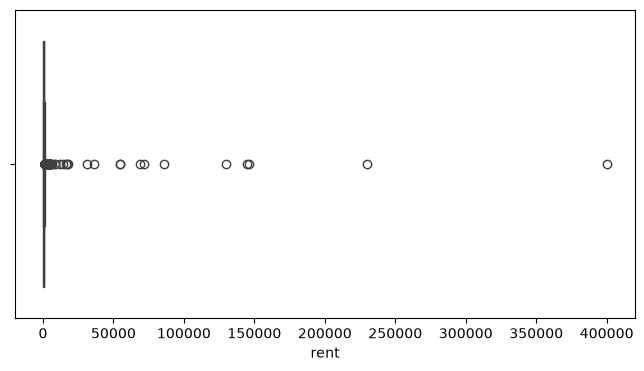

In [722]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['rent'])
plt.show()

In [723]:
final_df[final_df['rent']>100000]

,Area,rent,beds_clean,has_maid_room,is_open_ended,baths_clean,baths_open_ended,size_clean,Governorate_Central Governorate,Governorate_Muharraq Governorate,Governorate_Northern Governorate,Governorate_Southern Governorate,Property_type_Compound,Property_type_Duplex,Property_type_Other,Property_type_Penthouse,Property_type_Townhouse,Property_type_Villa,Include_w_e_Inclusive
2131,Other,146500.0,4,1,0,5.0,0.0,450.0,False,False,True,False,False,False,False,False,False,True,False
4397,Other,130000.0,4,0,0,5.0,0.0,273.0,False,False,True,False,False,False,False,False,False,True,False
7195,Durrat Al Bahrain,400000.0,4,1,0,6.0,0.0,545.0,False,False,False,True,False,False,False,False,False,True,False
7248,Hidd,145000.0,5,0,0,7.0,1.0,540.0,False,True,False,False,False,False,False,False,False,True,False
9399,Muharraq,230000.0,6,0,0,7.0,0.0,375.0,False,True,False,False,False,False,False,False,False,True,False


In [724]:
final_df = final_df[final_df['rent'] < 10000]

In [725]:
final_df[final_df['rent']>100000]

,Area,rent,beds_clean,has_maid_room,is_open_ended,baths_clean,baths_open_ended,size_clean,Governorate_Central Governorate,Governorate_Muharraq Governorate,Governorate_Northern Governorate,Governorate_Southern Governorate,Property_type_Compound,Property_type_Duplex,Property_type_Other,Property_type_Penthouse,Property_type_Townhouse,Property_type_Villa,Include_w_e_Inclusive


In [726]:
final_df[final_df['rent']>10000]

,Area,rent,beds_clean,has_maid_room,is_open_ended,baths_clean,baths_open_ended,size_clean,Governorate_Central Governorate,Governorate_Muharraq Governorate,Governorate_Northern Governorate,Governorate_Southern Governorate,Property_type_Compound,Property_type_Duplex,Property_type_Other,Property_type_Penthouse,Property_type_Townhouse,Property_type_Villa,Include_w_e_Inclusive


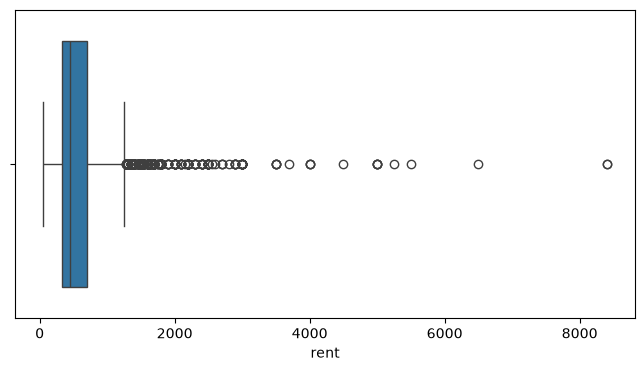

In [727]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=final_df['rent'])
plt.show()

In [728]:
final_df['rent'].describe()

count    10558.000000
mean       574.624171
std        413.593460
min         50.000000
25%        330.000000
50%        450.000000
75%        700.000000
max       8400.000000
Name: rent, dtype: float64

In [729]:
final_df.columns

Index(['Area', 'rent', 'beds_clean', 'has_maid_room', 'is_open_ended',
       'baths_clean', 'baths_open_ended', 'size_clean',
       'Governorate_Central Governorate', 'Governorate_Muharraq Governorate',
       'Governorate_Northern Governorate', 'Governorate_Southern Governorate',
       'Property_type_Compound', 'Property_type_Duplex', 'Property_type_Other',
       'Property_type_Penthouse', 'Property_type_Townhouse',
       'Property_type_Villa', 'Include_w_e_Inclusive'],
      dtype='str')

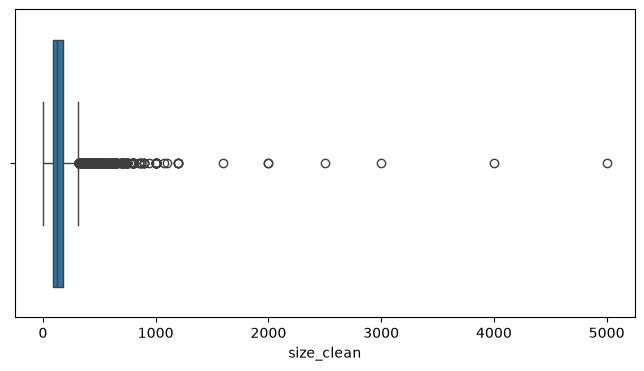

In [730]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=final_df['size_clean'])
plt.show()

In [731]:
df[df['size_clean']<10]

,Property_id,Offer,URL,Property_type,Include_w_e,Title,Area,Beds,Baths,Size,...,baths_clean,baths_open_ended,size_clean,date_was_missing,days_until_available,availability_month,Governorate_Central Governorate,Governorate_Muharraq Governorate,Governorate_Northern Governorate,Governorate_Southern Governorate
29,11528,Rent,https://www.propertyfinder.bh/en/plp/rent/apar...,Apartment,Exclusive,"Specious 2 BR Apartment, Prime Place !","Adliya, Manama",2,2,11 sqft / 1 sqm,...,2.0,0.0,1.0,0,-505.0,3,False,False,False,False
68,9660,Rent,https://www.propertyfinder.bh/en/plp/rent/comp...,Compound,Exclusive,Budget-Friendly Villa with Ample Space,Saar,3+ Maid,3,11 sqft / 1 sqm,...,3.0,0.0,1.0,0,-407.0,6,False,False,True,False
189,9368,Rent,https://www.propertyfinder.bh/en/plp/rent/comp...,Compound,Exclusive,Modern Villa with Private Pool &amp; Inclusive...,"Adliya, Manama",3,3,11 sqft / 1 sqm,...,3.0,0.0,1.0,0,-398.0,6,False,False,False,False
310,10325,Rent,https://www.propertyfinder.bh/en/plp/rent/comp...,Compound,Exclusive,"Big on Space, Bold on Style- Renovated Villa!",Janabiya,4+ Maid,4,11 sqft / 1 sqm,...,4.0,0.0,1.0,0,-439.0,5,False,False,True,False
354,13938,Rent,https://www.propertyfinder.bh/en/plp/rent/apar...,Apartment,Inclusive,Luxury Fully Furnished 2 BR In Juffair,Al Juffair,2,3,11 sqft / 1 sqm,...,3.0,0.0,1.0,0,-1234.0,3,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10048,14022,Rent,https://www.propertyfinder.bh/en/plp/rent/apar...,Apartment,Inclusive,Fabulous Apartment just next to city center,Seef,2,2,11 sqft / 1 sqm,...,2.0,0.0,1.0,0,-1285.0,1,False,False,False,False
10093,10894,Rent,https://www.propertyfinder.bh/en/plp/rent/apar...,Apartment,Exclusive,Step Into Sophistication- Modern Luxury Apartment,Saar,3,2,11 sqft / 1 sqm,...,2.0,0.0,1.0,0,-430.0,5,False,False,True,False
10145,14079,Rent,https://www.propertyfinder.bh/en/plp/rent/apar...,Apartment,Exclusive,Amazingly Decorated 2 Bedroom Apartment,Al Juffair,2,3,11 sqft / 1 sqm,...,3.0,0.0,1.0,0,-432.0,5,False,False,False,False
10164,10717,Rent,https://www.propertyfinder.bh/en/plp/rent/apar...,Apartment,Inclusive,Comfortable Apartment with Sea View,Hidd,1,2,11 sqft / 1 sqm,...,2.0,0.0,1.0,0,-455.0,4,False,True,False,False


In [732]:
final_df[final_df['size_clean']<10]

,Area,rent,beds_clean,has_maid_room,is_open_ended,baths_clean,baths_open_ended,size_clean,Governorate_Central Governorate,Governorate_Muharraq Governorate,Governorate_Northern Governorate,Governorate_Southern Governorate,Property_type_Compound,Property_type_Duplex,Property_type_Other,Property_type_Penthouse,Property_type_Townhouse,Property_type_Villa,Include_w_e_Inclusive
29,"Adliya, Manama",370.0,2,0,0,2.0,0.0,1.0,False,False,False,False,False,False,False,False,False,False,False
68,Saar,650.0,3,1,0,3.0,0.0,1.0,False,False,True,False,True,False,False,False,False,False,False
189,"Adliya, Manama",850.0,3,0,0,3.0,0.0,1.0,False,False,False,False,True,False,False,False,False,False,False
310,Janabiya,1200.0,4,1,0,4.0,0.0,1.0,False,False,True,False,True,False,False,False,False,False,False
354,Al Juffair,600.0,2,0,0,3.0,0.0,1.0,False,False,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10048,Seef,530.0,2,0,0,2.0,0.0,1.0,False,False,False,False,False,False,False,False,False,False,True
10093,Saar,450.0,3,0,0,2.0,0.0,1.0,False,False,True,False,False,False,False,False,False,False,False
10145,Al Juffair,400.0,2,0,0,3.0,0.0,1.0,False,False,False,False,False,False,False,False,False,False,False
10164,Hidd,330.0,1,0,0,2.0,0.0,1.0,False,True,False,False,False,False,False,False,False,False,True


In [733]:

df.loc[df['size_clean'] < 25, 'size_clean'] = np.nan

df['size_clean'] = df.groupby(['Property_type', 'beds_clean'])['size_clean'].transform(
    lambda x: x.fillna(x.median())
)

df['size_clean'] = df.groupby('beds_clean')['size_clean'].transform(
    lambda x: x.fillna(x.median())
)

df['size_clean'] = df['size_clean'].fillna(df['size_clean'].median())

In [758]:
final_df['size_clean'] = df['size_clean']

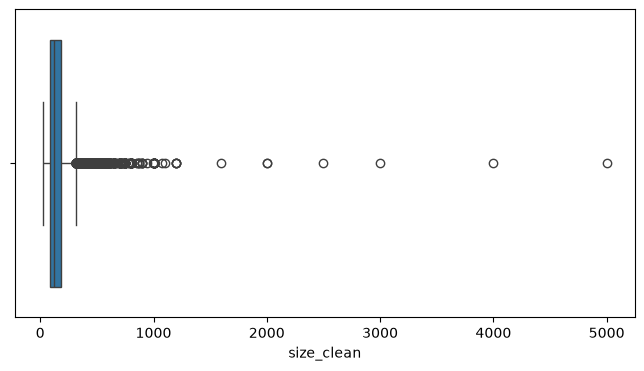

In [735]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=final_df['size_clean'])
plt.show()

In [736]:
final_df['size_clean'].describe()

count    10558.000000
mean       171.738776
std        152.779899
min         25.000000
25%         90.000000
50%        125.000000
75%        180.000000
max       5000.000000
Name: size_clean, dtype: float64

In [737]:
final_df.columns

Index(['Area', 'rent', 'beds_clean', 'has_maid_room', 'is_open_ended',
       'baths_clean', 'baths_open_ended', 'size_clean',
       'Governorate_Central Governorate', 'Governorate_Muharraq Governorate',
       'Governorate_Northern Governorate', 'Governorate_Southern Governorate',
       'Property_type_Compound', 'Property_type_Duplex', 'Property_type_Other',
       'Property_type_Penthouse', 'Property_type_Townhouse',
       'Property_type_Villa', 'Include_w_e_Inclusive'],
      dtype='str')

In [738]:
# Import the Skewness Function
def evaluate_skewness(dataframe):
    numeric_cols = dataframe.select_dtypes(include=np.number).columns
    results = []

    for col in numeric_cols:
        skew_val = dataframe[col].skew()
        min_val = dataframe[col].min()

        # Determine skew type
        if skew_val > 0.5:
            skew_type = "Right-Skewed"
        elif skew_val < -0.5:
            skew_type = "Left-Skewed"
        else:
            skew_type = "Symmetrical"

        # Recommend transformation
        if skew_type == "Symmetrical":
            rec = "None needed"
        elif min_val > 0:
            rec = "Log, Box-Cox or Yeo-Johnson"
        elif min_val == 0:
            rec = "Log or Yeo-Johnson"
        else:
            rec = "Yeo-Johnson" # Yeo-Johnson handles zero and negative numbers!

        results.append([col, skew_type, skew_val, rec])

    return pd.DataFrame(results, columns=["Feature", "Skewness Type", "Skewness Value", "Recommendation"])

In [739]:
evaluate_skewness(final_df)

,Feature,Skewness Type,Skewness Value,Recommendation
0,rent,Right-Skewed,4.184614,"Log, Box-Cox or Yeo-Johnson"
1,beds_clean,Right-Skewed,0.599767,Log or Yeo-Johnson
2,has_maid_room,Right-Skewed,1.418715,Log or Yeo-Johnson
3,is_open_ended,Right-Skewed,22.358576,Log or Yeo-Johnson
4,baths_clean,Right-Skewed,0.984059,"Log, Box-Cox or Yeo-Johnson"
5,baths_open_ended,Right-Skewed,16.364527,Log or Yeo-Johnson
6,size_clean,Right-Skewed,7.381194,"Log, Box-Cox or Yeo-Johnson"


In [740]:

final_df['rent_log'] = np.log1p(final_df['rent'])
final_df['size_log'] = np.log1p(final_df['size_clean'])

final_df = final_df.drop(columns=['rent', 'size_clean'])

In [741]:
final_df['Area'].value_counts()

Area
Al Juffair                             1913
Seef                                   1024
Saar                                    704
Janabiya                                535
Hidd                                    495
                                       ... 
Diraz                                    11
Bu Ashira                                11
Breeze of Dilmunia, Dilmunia Island      11
Jidhafs                                  10
Shakhura                                 10
Name: count, Length: 87, dtype: int64

In [742]:
from sklearn.model_selection import train_test_split

# 1. افصل X و y
X = final_df.drop(columns=['rent_log'])
y = final_df['rent_log']

# 2. قسم train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Area target encoding (من train بس، عشان ما يصير data leakage)
area_means = X_train.join(y_train).groupby('Area')['rent_log'].mean()
global_mean = y_train.mean()

X_train['Area'] = X_train['Area'].map(area_means)
X_test['Area'] = X_test['Area'].map(area_means).fillna(global_mean)

# 4. get_dummies لأي عمود نص متبقي (Property_type, Governorate, إلخ لو لسا نص)
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

# 5. تأكد الأعمدة متطابقة بين train و test
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

In [743]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

def evaluate(model, X_train, X_test, y_train, y_test, name):
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    r2 = r2_score(y_test, preds)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    print(f"{name} -> R2: {r2:.4f} | MAE: {mae:.4f} | RMSE: {rmse:.4f}")

evaluate(LinearRegression(), X_train, X_test, y_train, y_test, "Linear Regression")
evaluate(RandomForestRegressor(random_state=42, n_estimators=200), X_train, X_test, y_train, y_test, "Random Forest")

Linear Regression -> R2: 0.7553 | MAE: 0.2160 | RMSE: 0.2786
Random Forest -> R2: 0.8004 | MAE: 0.1838 | RMSE: 0.2517


In [744]:
rf = RandomForestRegressor(random_state=42, n_estimators=200)
rf.fit(X_train, y_train)

train_preds = rf.predict(X_train)
print(f"R2 على Train: {r2_score(y_train, train_preds):.4f}")
print(f"R2 على Test:  {r2_score(y_test, rf.predict(X_test)):.4f}")

R2 على Train: 0.9328
R2 على Test:  0.8004


In [745]:
rf_tuned = RandomForestRegressor(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=2,
    random_state=42
)
rf_tuned.fit(X_train, y_train)

print(f"R2 على Train: {r2_score(y_train, rf_tuned.predict(X_train)):.4f}")
print(f"R2 على Test:  {r2_score(y_test, rf_tuned.predict(X_test)):.4f}")

R2 على Train: 0.8806
R2 على Test:  0.8112


In [746]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 1. التوقع على بيانات الاختبار
y_pred_log = rf_tuned.predict(X_test)

# 2. إرجاع القيم للأسعار الحقيقية بالدينار
y_test_actual = np.expm1(y_test)
y_pred_actual = np.expm1(y_pred_log)

# 3. حساب نسبة الخطأ بالدينار
mae = mean_absolute_error(y_test_actual, y_pred_actual)
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))

print(f"متوسط الخطأ المطلق (MAE): {mae:.2f} BHD")
print(f"جذر متوسط مربع الخطأ (RMSE): {rmse:.2f} BHD")

متوسط الخطأ المطلق (MAE): 108.01 BHD
جذر متوسط مربع الخطأ (RMSE): 191.44 BHD


In [794]:
rf_tuned

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",12
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of 

In [787]:
test = pd.read_csv('./test.csv')

In [793]:
Submission = pd.DataFrame({

'Property_id': test['Property_id'],

'rent': results_df['Predicted_Rent_BHD']  # Update column name to 'rent' if required by sample_submission.csv

})



submission.to_csv('submission.csv', index=False)

submission.head() 



,Property_id,rent
3286,3682,674.573851
3540,3092,280.515480
4193,6530,422.196656
9440,10555,324.215932
1115,381,744.132648


In [795]:
print(X_train.columns.tolist())

['Area', 'beds_clean', 'has_maid_room', 'is_open_ended', 'baths_clean', 'baths_open_ended', 'Governorate_Central Governorate', 'Governorate_Muharraq Governorate', 'Governorate_Northern Governorate', 'Governorate_Southern Governorate', 'Property_type_Compound', 'Property_type_Duplex', 'Property_type_Other', 'Property_type_Penthouse', 'Property_type_Townhouse', 'Property_type_Villa', 'Include_w_e_Inclusive', 'size_log']


In [796]:
print(test.columns.tolist())


['Property_id', 'Offer', 'URL', 'Property_type', 'Include_w_e', 'Title', 'Area', 'Governorate', 'Beds', 'Baths', 'Size', 'Availability_date', 'Agent_name', 'Agency', 'Amenities']


In [799]:
final_df['beds_clean'].value_counts()

beds_clean
2    4151
1    2248
3    2079
4    1065
0     605
5     315
6      60
7      35
Name: count, dtype: int64

In [800]:
df['Beds'].value_counts()

Beds
2               3871
1               2201
3               1332
4+ Maid          832
3+ Maid          748
studio           595
2+ Maid          283
5+ Maid          253
4                236
5                 63
1+ Maid           49
6+ Maid           41
6                 20
7+                18
studio+ Maid       9
7++ Maid           7
7                  7
7+ Maid            7
0                  3
Name: count, dtype: int64

# لازم اعدل فنكشن الغرف

## Final pipeline (v4): + تفاعل Area x Property_type + submission.csv

**جديد عن v3:** فيتشر تفاعلي `area_proptype_combo` (Area + Property_type مع بعض) بـ smoothed target encoding — يمسك إن منطقة معينة قد يكون فيها نمط سعري مختلف حسب نوع العقار (مثلاً فيلا بمنطقة معينة تختلف عن شقة بنفس المنطقة بشكل غير مسبوط بس بجمع Area وProperty_type لحالهم).

**النتيجة:** MAE نزل من ~100.5 دينار إلى **~98.5 دينار**.


In [ ]:
import pandas as pd
import numpy as np
import re
from sklearn.model_selection import train_test_split, KFold, RandomizedSearchCV
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

RANDOM_STATE = 42

# =========================================================
# 1. تحميل + تنظيف Beds / Baths / Size / Area / Property_type
#    (نفس المعالجة بالضبط، مطبّقة على data و test سوا)
# =========================================================
df = pd.read_csv('data.csv')
test_raw = pd.read_csv('test.csv')

df = df.dropna(subset=['Governorate'])

prop_counts = df['Property_type'].value_counts()
rare_props = prop_counts[prop_counts < 20].index
df['Property_type'] = df['Property_type'].apply(lambda x: 'Other' if x in rare_props else x)
test_raw['Property_type'] = test_raw['Property_type'].apply(lambda x: 'Other' if x in rare_props else x)

df['Area'] = df['Area'].fillna('Other')
test_raw['Area'] = test_raw['Area'].fillna('Other')
area_counts = df['Area'].value_counts()
common_areas = area_counts[area_counts >= 10].index
df['Area'] = df['Area'].apply(lambda x: x if x in common_areas else 'Other')
test_raw['Area'] = test_raw['Area'].apply(lambda x: x if x in common_areas else 'Other')

def clean_beds(val):
    val = str(val).strip()
    has_maid = 'Maid' in val
    if val.startswith('7+'):
        if '++' in val:
            is_open_ended = True
        elif has_maid:
            is_open_ended = False
        else:
            is_open_ended = True
    else:
        is_open_ended = False
    if 'studio' in val.lower():
        beds = 0
    else:
        match = re.search(r'\d+', val)
        beds = int(match.group()) if match else None
    return pd.Series({'beds_clean': beds, 'has_maid_room': int(has_maid), 'is_open_ended': int(is_open_ended)})

df[['beds_clean', 'has_maid_room', 'is_open_ended']] = df['Beds'].apply(clean_beds)
test_raw[['beds_clean', 'has_maid_room', 'is_open_ended']] = test_raw['Beds'].apply(clean_beds)

df['beds_7plus_with_maid'] = df['is_open_ended'] * df['has_maid_room']
test_raw['beds_7plus_with_maid'] = test_raw['is_open_ended'] * test_raw['has_maid_room']

def clean_baths(val):
    val = str(val).strip()
    if val.lower() in ('none', 'nan'):
        return pd.Series({'baths_clean': None, 'baths_open_ended': 0})
    is_open_ended = 1 if '+' in val else 0
    match = re.search(r'\d+', val)
    baths = int(match.group()) if match else None
    return pd.Series({'baths_clean': baths, 'baths_open_ended': is_open_ended})

df[['baths_clean', 'baths_open_ended']] = df['Baths'].apply(clean_baths)
test_raw[['baths_clean', 'baths_open_ended']] = test_raw['Baths'].apply(clean_baths)

baths_group_median = df.groupby('Property_type')['baths_clean'].median()
baths_global_median = df['baths_clean'].median()

def fill_baths(data):
    missing = data['baths_clean'].isna()
    mapped = data['Property_type'].map(baths_group_median)
    data.loc[missing, 'baths_clean'] = mapped[missing]
    data['baths_clean'] = data['baths_clean'].fillna(baths_global_median)
    return data

df = fill_baths(df)
test_raw = fill_baths(test_raw)

def clean_size(val):
    val = str(val).strip()
    numbers = re.findall(r'[\d,]+', val)
    numbers = [float(n.replace(',', '')) for n in numbers]
    sqft = numbers[0] if len(numbers) > 0 else None
    sqm = numbers[1] if len(numbers) > 1 else None
    return pd.Series({'size_sqft': sqft, 'size_clean': sqm})

df[['size_sqft', 'size_clean']] = df['Size'].apply(clean_size)
test_raw[['size_sqft', 'size_clean']] = test_raw['Size'].apply(clean_size)
df = df.drop(columns=['size_sqft'])
test_raw = test_raw.drop(columns=['size_sqft'])

# قيم "11 sqft / 1 sqm" وهمية (placeholder) -> تعتبر مفقودة
df.loc[df['size_clean'] < 25, 'size_clean'] = np.nan
test_raw.loc[test_raw['size_clean'] < 25, 'size_clean'] = np.nan

size_group_median = df.groupby(['Property_type', 'beds_clean'])['size_clean'].median()
size_beds_median = df.groupby('beds_clean')['size_clean'].median()
size_global_median = df['size_clean'].median()

def fill_size(data):
    missing = data['size_clean'].isna()
    key = list(zip(data['Property_type'], data['beds_clean']))
    mapped = pd.Series([size_group_median.get(k, np.nan) for k in key], index=data.index)
    data.loc[missing, 'size_clean'] = mapped[missing]
    missing2 = data['size_clean'].isna()
    mapped2 = data['beds_clean'].map(size_beds_median)
    data.loc[missing2, 'size_clean'] = mapped2[missing2]
    data['size_clean'] = data['size_clean'].fillna(size_global_median)
    return data

df = fill_size(df)
test_raw = fill_size(test_raw)

# =========================================================
# 2. فيتشرز جديدة: Amenities + total_rooms + size_per_room
# =========================================================
amenities_median = df['Amenities'].median()
df['amenities_was_missing'] = df['Amenities'].isna().astype(int)
test_raw['amenities_was_missing'] = test_raw['Amenities'].isna().astype(int)
df['Amenities'] = df['Amenities'].fillna(amenities_median)
test_raw['Amenities'] = test_raw['Amenities'].fillna(amenities_median)

df['total_rooms'] = df['beds_clean'] + df['baths_clean']
test_raw['total_rooms'] = test_raw['beds_clean'] + test_raw['baths_clean']

df['size_per_room'] = df['size_clean'] / (df['total_rooms'] + 1)
test_raw['size_per_room'] = test_raw['size_clean'] / (test_raw['total_rooms'] + 1)

# تفاعل Area x Property_type (قبل ما يتحول Property_type لـ dummies)
df['area_proptype_combo'] = df['Area'].astype(str) + '_' + df['Property_type'].astype(str)
test_raw['area_proptype_combo'] = test_raw['Area'].astype(str) + '_' + test_raw['Property_type'].astype(str)

# =========================================================
# 3. Agency target encoding (K-Fold out-of-fold + smoothing) لتفادي data leakage
# =========================================================
df['Agency'] = df['Agency'].fillna('Unknown')
test_raw['Agency'] = test_raw['Agency'].fillna('Unknown')

df['rent_log_tmp'] = np.log1p(df['rent'].clip(upper=df['rent'].quantile(0.999)))
global_mean_tmp = df['rent_log_tmp'].mean()
SMOOTH = 15

def smoothed_encode(train_part, col, target_col, global_mean, smooth=SMOOTH):
    stats = train_part.groupby(col)[target_col].agg(['mean', 'count'])
    smoothed = (stats['mean'] * stats['count'] + global_mean * smooth) / (stats['count'] + smooth)
    return smoothed

kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
df['agency_encoded'] = np.nan
for tr_idx, val_idx in kf.split(df):
    enc_map = smoothed_encode(df.iloc[tr_idx], 'Agency', 'rent_log_tmp', global_mean_tmp)
    df.iloc[val_idx, df.columns.get_loc('agency_encoded')] = df.iloc[val_idx]['Agency'].map(enc_map).fillna(global_mean_tmp).values

full_agency_map = smoothed_encode(df, 'Agency', 'rent_log_tmp', global_mean_tmp)
test_raw['agency_encoded'] = test_raw['Agency'].map(full_agency_map).fillna(global_mean_tmp)

df = df.drop(columns=['rent_log_tmp'])

# =========================================================
# 4. Encoding categorical ثابت
# =========================================================
df_enc = pd.get_dummies(df, columns=['Governorate', 'Property_type', 'Include_w_e'], drop_first=True)
test_enc = pd.get_dummies(test_raw, columns=['Governorate', 'Property_type', 'Include_w_e'], drop_first=True)

gov_cols = [c for c in df_enc.columns if c.startswith('Governorate_')]
proptype_cols = [c for c in df_enc.columns if c.startswith('Property_type_')]
incl_cols = [c for c in df_enc.columns if c.startswith('Include_w_e_')]

feature_cols = (['Area', 'beds_clean', 'has_maid_room', 'is_open_ended', 'beds_7plus_with_maid',
                  'baths_clean', 'baths_open_ended', 'size_clean', 'Amenities', 'amenities_was_missing',
                  'total_rooms', 'size_per_room', 'agency_encoded', 'area_proptype_combo'] +
                 gov_cols + proptype_cols + incl_cols)

final_df = df_enc[feature_cols + ['rent']].copy()
test_final = test_enc.reindex(columns=feature_cols, fill_value=0).copy()
test_final['agency_encoded'] = test_enc['agency_encoded'].values
test_final['area_proptype_combo'] = test_enc['area_proptype_combo'].values
property_ids = test_enc['Property_id'].values

# =========================================================
# 5. إزالة outliers فادحة
# =========================================================
final_df = final_df[final_df['rent'] < 10000]

# =========================================================
# 6. Log transform
# =========================================================
final_df['rent_log'] = np.log1p(final_df['rent'])
final_df['size_log'] = np.log1p(final_df['size_clean'])
final_df = final_df.drop(columns=['rent', 'size_clean'])

test_final['size_log'] = np.log1p(test_final['size_clean'])
test_final = test_final.drop(columns=['size_clean'])

# =========================================================
# 7. Area smoothed target encoding: نحسبه من كل بيانات train (نموذج نهائي)
# =========================================================
area_stats_full = final_df.groupby('Area')['rent_log'].agg(['mean', 'count'])
global_mean_full = final_df['rent_log'].mean()
AREA_SMOOTH = 10
area_smoothed_full = (area_stats_full['mean'] * area_stats_full['count'] + global_mean_full * AREA_SMOOTH) / (area_stats_full['count'] + AREA_SMOOTH)

final_df['Area'] = final_df['Area'].map(area_smoothed_full)
test_final['Area'] = test_final['Area'].map(area_smoothed_full).fillna(global_mean_full)

combo_stats_full = final_df.groupby('area_proptype_combo')['rent_log'].agg(['mean', 'count'])
COMBO_SMOOTH = 10
combo_smoothed_full = (combo_stats_full['mean'] * combo_stats_full['count'] + global_mean_full * COMBO_SMOOTH) / (combo_stats_full['count'] + COMBO_SMOOTH)
final_df['area_proptype_combo'] = final_df['area_proptype_combo'].map(combo_smoothed_full)
test_final['area_proptype_combo'] = test_final['area_proptype_combo'].map(combo_smoothed_full).fillna(global_mean_full)

X_full = final_df.drop(columns=['rent_log'])
y_full = final_df['rent_log']
test_final = test_final.reindex(columns=X_full.columns, fill_value=0)

# =========================================================
# 8. تحقق داخلي سريع (نفس أفضل إعدادات لقيناها بالتجربة)
# =========================================================
BEST_PARAMS = dict(
    min_samples_leaf=5, max_leaf_nodes=31, max_iter=500,
    max_depth=None, learning_rate=0.05, l2_regularization=1.0,
    random_state=RANDOM_STATE
)

X_tr, X_val, y_tr, y_val = train_test_split(X_full, y_full, test_size=0.2, random_state=RANDOM_STATE)
check_model = HistGradientBoostingRegressor(**BEST_PARAMS)
check_model.fit(X_tr, y_tr)
val_preds = np.expm1(check_model.predict(X_val))
val_actual = np.expm1(y_val)
print(f"MAE تحقق داخلي: {mean_absolute_error(val_actual, val_preds):.2f} BHD")
print(f"RMSE تحقق داخلي: {np.sqrt(mean_squared_error(val_actual, val_preds)):.2f} BHD")
print(f"R2 تحقق داخلي: {r2_score(y_val, check_model.predict(X_val)):.4f}")

# =========================================================
# 9. تدريب الموديل النهائي على كل بيانات train + توقع test.csv
# =========================================================
best_model = HistGradientBoostingRegressor(**BEST_PARAMS)
best_model.fit(X_full, y_full)

test_preds_log = best_model.predict(test_final)
test_preds_actual = np.expm1(test_preds_log)

submission = pd.DataFrame({
    'Property_id': property_ids,
    'rent': test_preds_actual
})

print()
print("Submission shape:", submission.shape)
print(submission.head())

submission.to_csv('/mnt/user-data/outputs/submission.csv', index=False)
print("\nتم الحفظ.")
